In [ ]:
import nico 
from nico import Annotations as sann
from nico import Interactions as sint
from nico import Covariations as scov

import scanpy as sc
import gseapy
import xlsxwriter

import numpy as np
import time
import os

import matplotlib as plt 


In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 0.1 #set the value globally

# please use Helvetica font according to your OS to make compatible with Adobe Illustrator. 
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# Use the default font for all the figures 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans','Lucida Grande', 'Verdana']

import warnings
warnings.filterwarnings("ignore")

### Usage introduction 
For details of the function usage and input parameters either refer to the documentation or  <br>
just write the function and add .__doc__ to retrieve infromation on all relelvant parameters.

print(sann.find_anchor_cells_between_ref_and_query.__doc__) <br>
print(sint.spatial_neighborhood_analysis.__doc__) <br>
print(scov.gene_covariation_analysis.__doc__) <br>

All the figures will be saved in ``saveas=pdf`` format as vector graphics by default. <br>
For every function that generates  figures, the following default parameters are used: <br>
transparent_mode=False, saveas='pdf',showit=True, dpi=300 

For saving figures in png format, set saveas='png'  <br>
For generating images without background, set transparent_mode=True <br>
If figure outputs within the Jupyter Notebook is not desired, set showit=False

Please download the sample data from the git <br> repository 
https://github.com/ankitbioinfo/nico_tutorial and <br> keep all the files and folders in the same directory to complete the tutorial. 

inputRef  (single-cell RNA-sequencing data)  <br>
inputQuery (single-cell resolution spatial transcriptomics data) <br>
NiCoLRdb.txt (Ligand-receptor database file) 

Before running the Perform_spatial_analysis.ipynb notebook, <br> input data need to be prepared by running  <br>
the Start_Data_preparation_for_niche_analysis.ipynb notebook <br>
Once all the steps of Start_Data_preparation_for_niche_analysis.ipynb are completed, <br> the following commands can be executed to run a complete NiCo aanlysis. 

In [3]:
#parameters for saving plots
saveas='png'
transparent_mode=False

In [4]:
ref_datapath='./inputRef/'
query_datapath='./inputQuery/'



output_nico_dir='./nico_out0.6_2/'
output_annotation_dir=None #uses default location
#output_annotation_dir=output_nico_dir+'annotations/'
inputRadius=0
annotation_save_fname= 'nico_celltype_annotation.h5ad'



The cell type cluster slot in scRNAseq data is ``ref_cluster_tag`` <br>
For example in AnnData object the location of slot:  adata.obs['cluster'] <br>
In this slot cell type annotation of scRNAseq data is stored 

In [5]:
ref_cluster_tag='cell_type' #scRNAseq cell type slot 
annotation_slot='nico_ct' #spatial cell type slot 

# Module A: Perform cell type annotation of spatial data 

First find anchored cells between two modalities 


In [6]:
##'''run only if ann not available
anchors_and_neighbors_info=sann.find_anchor_cells_between_ref_and_query(
refpath=ref_datapath,
quepath=query_datapath,
output_nico_dir=output_nico_dir,
output_annotation_dir=output_annotation_dir)
#'''


### Selection of parameters 
Perform NiCo cell type annotation using the spatial Leiden cluster from the <br> Start_Data_preparation_for_niche_analysis.ipynb notebook, <br>
e.g., with Leiden resolution parameter 0.4  <br>



If you have a large number of cells (>200,000) and want to perform <br>
cell type annotation with different Leiden resolution parameters or <br>
any other parameters, save the output_annotation_dir directory with <br>
a different name for each run.

MNN (Mutual Nearest Neighbors) alignment takes a considerable amount <br>
of time, which can delay the analysis in ordinary laptop. Therefore, it is <br>
advisable to save the anchors_data_50.npz file, as the anchor information is <br>
independent of the resolution parameter.  

### The annotation slot in scRNAseq data and initial cluster slot in spatial data 
ref_cluster_tag='cluster' <br>
#### ref_cluster_tag define the cellType slot for scRNAseq data. <br>
Example  .obs['cluster']  <br>
#### If scRNAseq cellType is stored with some other slot then please change the slot name <br>

guiding_spatial_cluster_resolution_tag='leiden0.4' <br>
guiding_spatial_cluster_resolution_tag define the Leiden clustering slot for spatial data. <br>
Example .obs['leiden0.4']

In [7]:
#'''run if no annotation available
output_info=sann.nico_based_annotation(anchors_and_neighbors_info,
guiding_spatial_cluster_resolution_tag='leiden0.6',
across_spatial_clusters_dispersion_cutoff=0.15,ref_cluster_tag='cell_type',
resolved_tie_issue_with_weighted_nearest_neighbor='No')
#'''

This function ``sann.delete_files`` deletes the anchored file details <br>
created in the ``find_anchor_cells_between_ref_and_query`` step.  <br>
If you have a large number of cells and want to experiment different  <br>
annotation parameters, do not delete this file as it can save a <br>
significant amount of time. 

In [8]:
#'''
sann.delete_files(output_info)
#'''

In [9]:
# Visualize the anchor cells between two modalities. 
# sann.visualize_spatial_anchored_cell_mapped_to_scRNAseq(output_info)

### Save the annotation file into AnnData object

Save the annotation file into AnnData object (annotation_save_fname) <br>
along with given expression matrix in "output_nico_dir" directory. 


In [10]:
##'''
sann.save_annotations_in_spatial_object(output_info,
anndata_object_name=annotation_save_fname)
#'''

Nico based cluster annotations are saved in .obs['nico_ct'] slot


In [11]:
#annotation_save_fname= 'modify_nico_celltype_annotation.h5ad' #if change the id of nico cluster, then change this to the new h5ad


## Note: Annotations from different computational methods such cell2location or TACCO 

If user have an AnnData object with cell type annotations <br>
from different methods, you can skip the previous steps. 

To use your own annotations, provide the following files:  <br>
annotation_save_fname= 'nico_celltype_annotation.h5ad'    <br>

Replace the annotation_save_fname AnnData object <br> 
with your own AnnData object containing the annotations. <br>
Ensure that the annotation slot name in your AnnData object <br>
is adjusted to match the following: 

annotation_slot='nico_ct' 

This will ensure compatibility with the NiCo pipeline.



### Visualize the spatial annotations of all cell types 
Left side: tissue map, Right side: UMAP 

The figures are saved:  ./nico_out0.6_2/annotations/tissue_and_umap_with_all_celltype_annotations.pdf


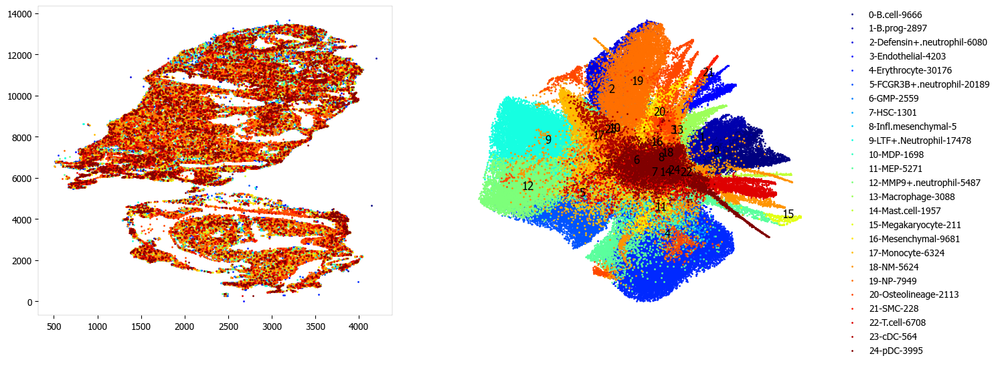

In [12]:
sann.visualize_umap_and_cell_coordinates_with_all_celltypes( 
output_nico_dir=output_nico_dir,
output_annotation_dir=output_annotation_dir,
anndata_object_name=annotation_save_fname,
#spatial_cluster_tag='nico_ct',
spatial_cluster_tag=annotation_slot,    
spatial_coordinate_tag='spatial',
umap_tag='X_umap',
saveas='pdf',transparent_mode=transparent_mode)

### Visualize  spatial annotations of selected pairs (or larger sets) of cell types  
Left side: tissue map, Right side: UMAP 

In [13]:
''''
choose_celltypes=[]

sann.visualize_umap_and_cell_coordinates_with_selected_celltypes(
choose_celltypes=choose_celltypes,    
output_nico_dir=output_nico_dir,
output_annotation_dir=output_annotation_dir,
anndata_object_name=annotation_save_fname,
spatial_cluster_tag=annotation_slot,spatial_coordinate_tag='spatial',umap_tag='X_umap',
saveas=saveas,transparent_mode=transparent_mode)
'''

"'\nchoose_celltypes=[]\n\nsann.visualize_umap_and_cell_coordinates_with_selected_celltypes(\nchoose_celltypes=choose_celltypes,    \noutput_nico_dir=output_nico_dir,\noutput_annotation_dir=output_annotation_dir,\nanndata_object_name=annotation_save_fname,\nspatial_cluster_tag=annotation_slot,spatial_coordinate_tag='spatial',umap_tag='X_umap',\nsaveas=saveas,transparent_mode=transparent_mode)\n"

In [14]:
# For visualizing every cell type individually, leave list choose_celltypes list empty.  
#sann.visualize_umap_and_cell_coordinates_with_selected_celltypes(choose_celltypes=[])

# Module B: Infer significant niche cell type interactions 

### Radius definition 

The radius R=0 in NiCo incorporates the neighboring cells that are in immediate contact with <br>
the central cell to construct the expected neighborhood composition matrix.  <br>
We envision NiCo as a method to explore direct interactions with physical neighbors <br>
(R=0), but in principle finite distance interactions mediated by diffusive factors could be <br>
explored by increasing R and comparing to the interactions obtained with R=0.  

It may be helpful to explore a larger radius if it is expected that cell types interact through long-range <br>
interactions. However, during the covariation task immediate neighbors typically capture the <br>
strongest signal, while a larger radius averages the signal from a more significant number of <br>
cells, potentially diluting the signal. Therefore, we recommend running NiCo with R=0. 


Perform  neighborhood analysis across direct neighbors <br> 
(juxtacrine signaling, R=0) of the central niche cell type.   

To exclude cell types from the neighborhood analysis, <br> 
add celltype names to the list removed_CTs_before_finding_CT_CT_interactions. <br>

In the example below, the cell types Basophils, Cycling/GC B cell, <br>
and pDC, would not be included in the niche interaction task due to their low abundance. 

In [15]:
do_not_use_following_CT_in_niche=[]

niche_pred_output=sint.spatial_neighborhood_analysis(
Radius=inputRadius,
output_nico_dir=output_nico_dir,
anndata_object_name=annotation_save_fname,
spatial_cluster_tag='nico_ct',
removed_CTs_before_finding_CT_CT_interactions=do_not_use_following_CT_in_niche)


average neighbors: 5.96669514376485
average distance: 11.933709722578639
data shape (149800, 26) (149800,) neighbor shape (149800, 24)
Searching hyperparameters  Grid method: 0.001953125
Searching hyperparameters  Grid method: 0.0009765625
Searching hyperparameters  Grid method: 0.0009765625
Inverse of lambda regularization found 0.0009765625
training (119840, 24) testing (29960, 24) coeff (24, 24)


In [25]:
# this cutoff is use for the visualization of cell type interactions network 
celltype_niche_interaction_cutoff=0.04


In some computing machine pygraphviz is not able to load the neato package automatically. <br>
In such case please define the location of the neato package.  <br>
If you install pygraphviz through conda ```conda install -c conda-forge pygraphviz``` <br>
then most likely it should work. 
```
import pygraphviz
a=pygraphviz.AGraph()
a._get_prog('neato')

import os
if  not '/home/[username]/miniforge3/envs/SC/bin/' in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + '/home/[username]/miniforge3/envs/SC/bin/'
```

The figures are saved:  ./nico_out0.6_2/niche_prediction_linear/Niche_interactions_without_edge_weights_R0..pdf


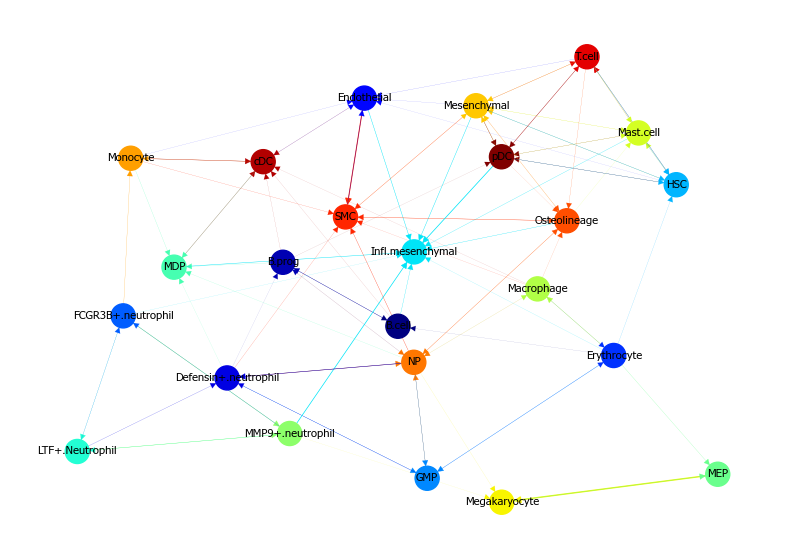

In [ ]:
# Plot the niche interaction network without any edge weight details 

sint.plot_niche_interactions_without_edge_weight(niche_pred_output,
niche_cutoff=celltype_niche_interaction_cutoff,
saveas=".pdf",transparent_mode=transparent_mode)


The figures are saved:  ./nico_out0.6_2/niche_prediction_linear/Niche_interactions_with_edge_weights_R0.png


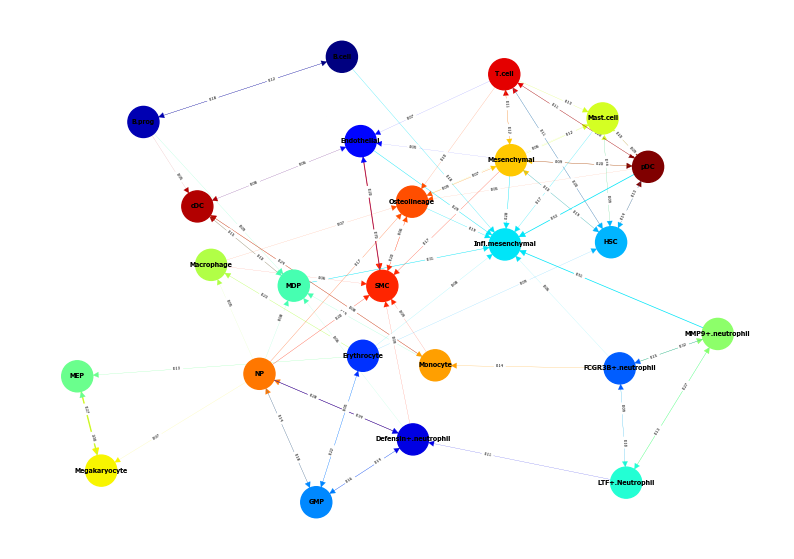

In [ ]:
# Plot the niche interaction network with edge weight details 

sint.plot_niche_interactions_with_edge_weight(niche_pred_output,
niche_cutoff=celltype_niche_interaction_cutoff,
saveas=saveas,transparent_mode=transparent_mode)


### Cell type niche plot individually 

Order niche cell types by magnitude of regression coefficients, <br> add celltype names to the list argument 
choose_celltypes, <br> e.g., for the Stem/TA and Paneth cell niche. 

In [ ]:
# Blue dotted line in following plot is celltype_niche_interaction_cutoff

sint.find_interacting_cell_types(niche_pred_output,
choose_celltypes=[],
celltype_niche_interaction_cutoff=celltype_niche_interaction_cutoff,
saveas=saveas,transparent_mode=transparent_mode,figsize=(4.0,2.0))

If niche cell types from the niche neighborhood of all central <br>
cell types should be plotted or saved, <br>
then leave choose_celltypes list argument empty. 

In [ ]:
#sint.find_interacting_cell_types(niche_pred_output,choose_celltypes=[])

In [ ]:
# Plot the ROC curve of the classifier prediction for one of the crossfolds. 
# sint.plot_roc_results(niche_pred_output,saveas=saveas,transparent_mode=transparent_mode))
# sint.plot_predicted_probabilities(niche_pred_output)


Plot the average confusion matrix of the classifier from cross-folds 

The figures are saved:  ./nico_out0.6/niche_prediction_linear/Confusing_matrix_R0.png


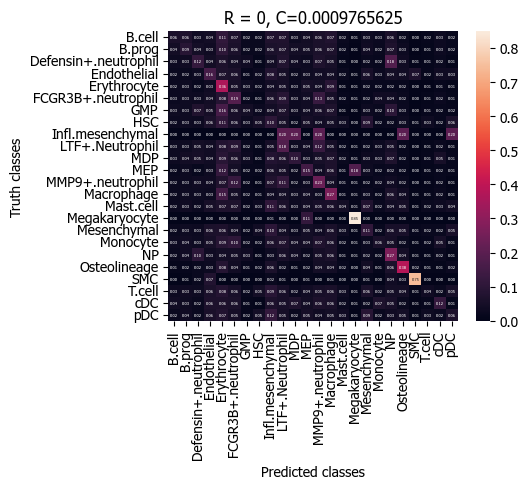

In [45]:
sint.plot_confusion_matrix(niche_pred_output,
saveas=saveas,transparent_mode=transparent_mode)

Plot the average coefficient matrix of the classifier from cross-folds 

The figures are saved:  ./nico_out0.6/niche_prediction_linear/weight_matrix_R0.png


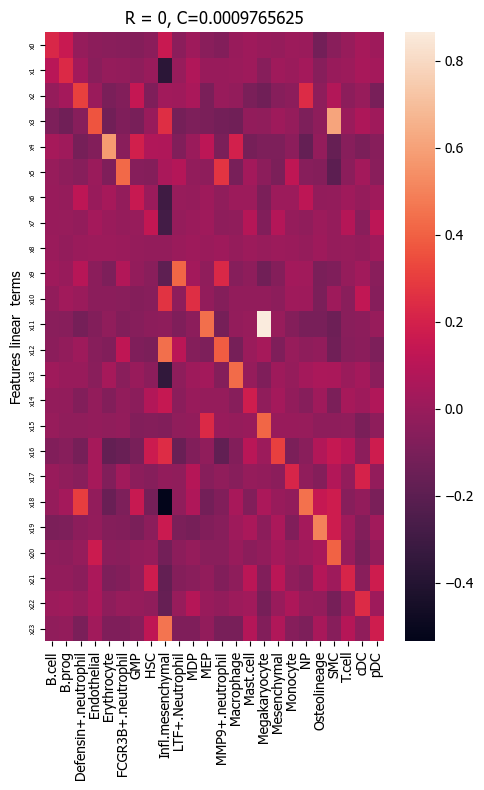

In [46]:
sint.plot_coefficient_matrix(niche_pred_output,
saveas=saveas,transparent_mode=transparent_mode)

Plot the evaluation score of the classifier for different metrics 

The figures are saved:  ./nico_out0.6/niche_prediction_linear/scores_0.png


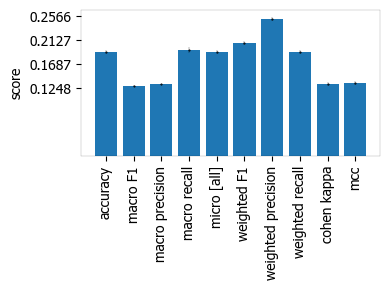

In [47]:
sint.plot_evaluation_scores(niche_pred_output, 
saveas=saveas, transparent_mode=transparent_mode,
figsize=(4,3))

# Module C: Perform niche cell state covariation analysis using latent factors

Note: From module C onwards, Jupyter cells are independent of previous steps. <br>
Therefore, if you want to try different settings, you do not need to run the previous Jupyter cells.

### Covariations parameters settings 
Infer desired number of latent factors (e.g., no_of_factors=3) for each cell type <br> from both modalities using 
integrated non-negative matrix factorization. <br>
Set iNMFmode=False for applying the conventional <br> non-negative matrix factorization method. <br> In this case, latent factors 
will be derived from the scRNA-seq data <br> and transfered to the spatial modality. 

This option is preferable if spatial data are affected by substantial <br> technical noise due to unspecific background signal <br> 
or gene expression spill-over between neighboring <br> cell types due to imperfect segmentation.

### Ligand-Receptor database file 
NiCoLRdb.txt is the name of the ligand-receptor database file. <br> Users can use databases of similar format from any resource. <br>

NiCoLRdb.txt was created by merging ligand-receptor pairs from NATMI, OMNIPATH, and CellPhoneDB. <br>
User can download this database from github <br> and put into local directory <br> from where this notebook is getting run. 

In [48]:
# By default, it run in spatial_integration_modality='double' that means 
# it integrates spatial transcriptomics with scRNAseq data modalities 

cov_out=scov.gene_covariation_analysis(iNMFmode=True,
        Radius=inputRadius,
        no_of_factors=3,
        refpath=ref_datapath,
        quepath=query_datapath,
        spatial_integration_modality='double',
        output_niche_prediction_dir=output_nico_dir,
        ref_cluster_tag=ref_cluster_tag)

common genes between sc and sp 379 379


 Spatial and scRNA-seq number of clusters, respectively  24 24
Common cell types between spatial and scRNA-seq data   24 {'T.cell', 'LTF+.Neutrophil', 'Erythrocyte', 'MDP', 'GMP', 'Endothelial', 'MMP9+.neutrophil', 'Megakaryocyte', 'Mast.cell', 'HSC', 'B.prog', 'cDC', 'NP', 'FCGR3B+.neutrophil', 'pDC', 'Defensin+.neutrophil', 'Osteolineage', 'Mesenchymal', 'Infl.mesenchymal', 'B.cell', 'Monocyte', 'SMC', 'Macrophage', 'MEP'}

The spatial cluster name does not match the scRNA-seq cluster name  set()
If the above answer is Null, then everything is okay. However, if any spatial cell type does not exist in the scRNA-seq data, please correct this manually; otherwise, NiCo will not run. 



B.cell alpha, H size, W size, spH size: 30 (3, 312) (262, 3) (3, 9666)
B.prog alpha, H size, W size, spH size: 14 (3, 775) (328, 3) (3, 2897)
Endothelial alpha, H size, W size, spH size: 4 (3, 20) (150, 3) (3, 4203)
Erythrocyte alpha, H size, W size, spH size: 12 (

### Visualize the cosine similarity and Spearman correlation between genes and latent factors 

Following function generates output for the top 30 genes <br> based on cosine similarity (left) or Spearman correlation (right) 

Select cell types by adding IDs to list argument choose_celltypes, <br> or leave empty for generating output for all cell types

In [ ]:
scov.plot_cosine_and_spearman_correlation_to_factors(cov_out,
choose_celltypes=[],
NOG_Fa=30,saveas=saveas,transparent_mode=transparent_mode,
figsize=(15,10))

In [ ]:
#Cosine and spearman correlation: visualize the correlation of genes from NMF
scov.plot_cosine_and_spearman_correlation_to_factors(cov_out,
choose_celltypes=[],
NOG_Fa=30,saveas=saveas,transparent_mode=transparent_mode,
figsize=(15,10))

### Visualize genes in the latent factors along with average expression 
Call following function (scov.extract_and_plot_top_genes_from_chosen_factor_in_celltype) to <br> visualize correlation and expression of genes associated with factors

For example, visualize and extract the top 10 genes (top_NOG=20) <br>
correlating negatively (positively_correlated=False) <br>
by Spearman correlation (correlation_with_spearman=True) <br>
for cell type Stem/TA (choose_celltype='Stem/TA') <br>
in factor 1 (choose_factor_id=1)


In [51]:
dataFrame=scov.extract_and_plot_top_genes_from_chosen_factor_in_celltype(
cov_out,
choose_celltype=[],
choose_factor_id=1,
top_NOG=20,
correlation_with_spearman=True,
positively_correlated=False,
saveas=saveas,transparent_mode=transparent_mode )

Cell type name do not match


### Visualize the latent factor values and proportion of population expressed that gene 
inspect the top genes in the given factor as in table <br>
proportion_of_population_expressed:  <br> proportion of cells expressing a gene in the respective cluster 


In [52]:
dataFrame

0

### Save the latent factors into excel sheet 
save data in an Excel sheet for each cell type, <br> including latent factor associations of all genes according to <br>
Spearman correlation and cosine similarity. 

In [53]:
scov.make_excel_sheet_for_gene_correlation(cov_out)

# Module D: Cell type covariation visualization   

Plot covariations between niche cell types (x-axis) and central cell type<br> (y-axis, defined by list argument choose_celltypes). 

Circle size scales with -log10(p-value) (indicated as number on top of each circle). <br>
To generate plots for all cell types, leave list argument choose_celltypes empty. 

The regression figures as pvalue circle plots are saved in following path  ./nico_out0.6/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_*


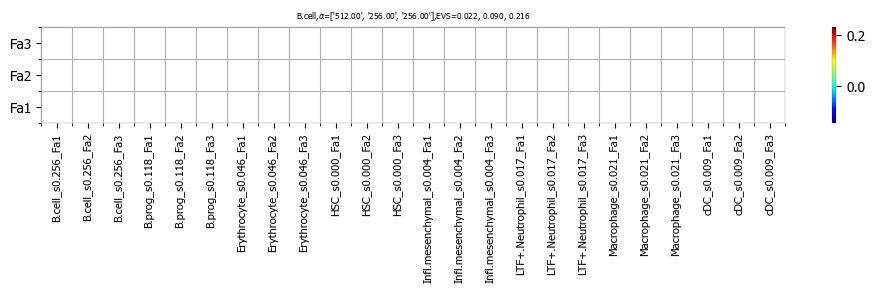

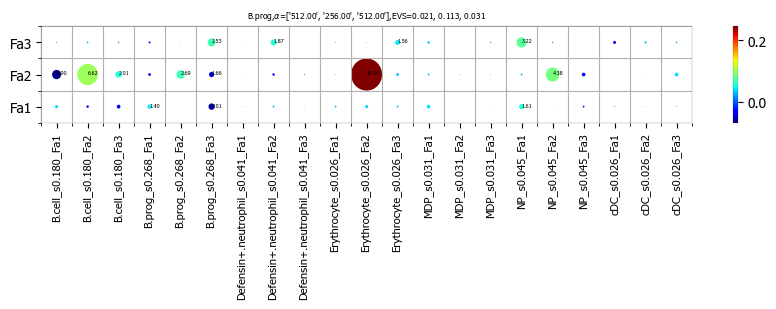

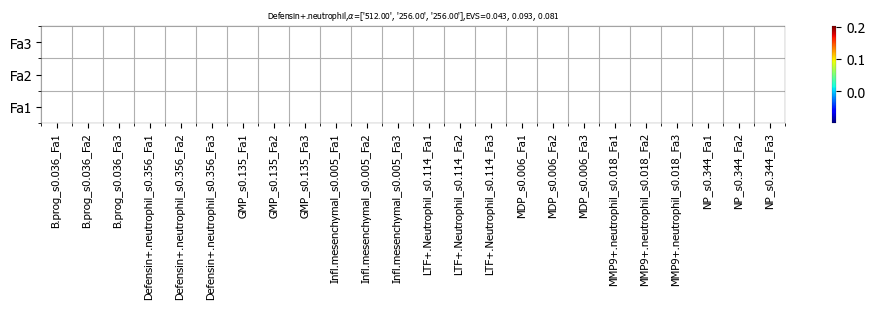

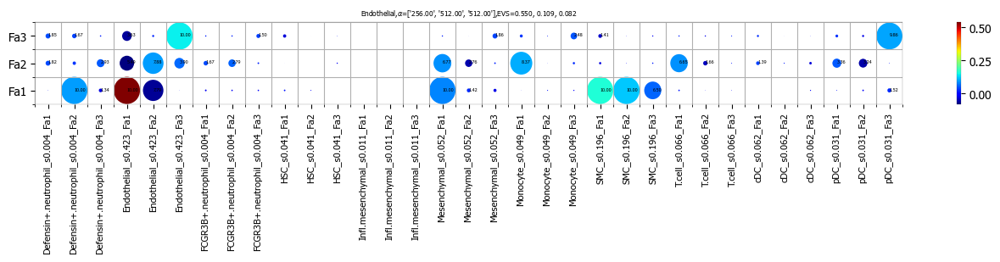

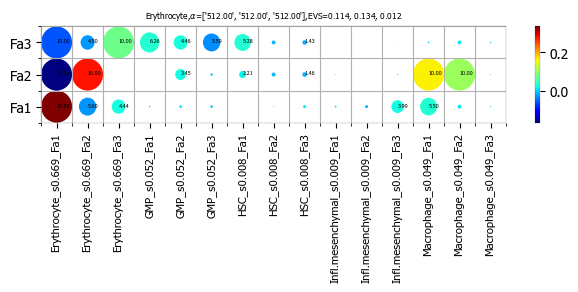

...

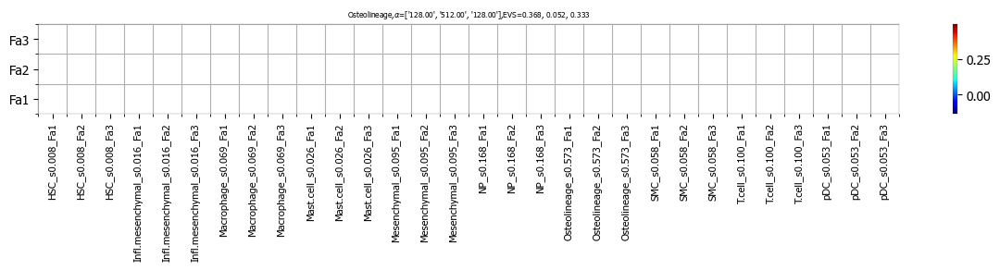

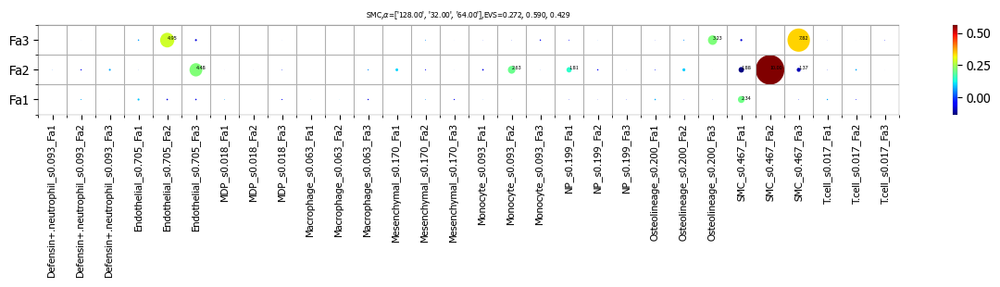

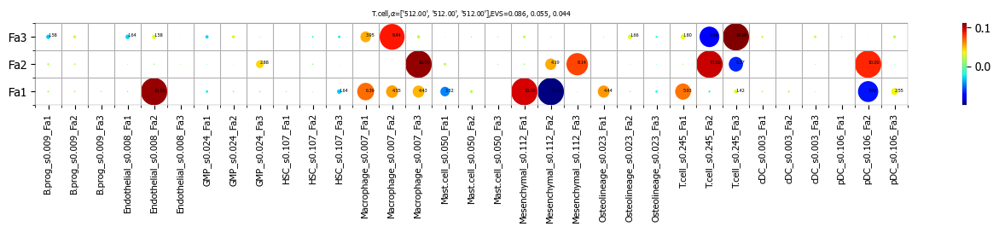

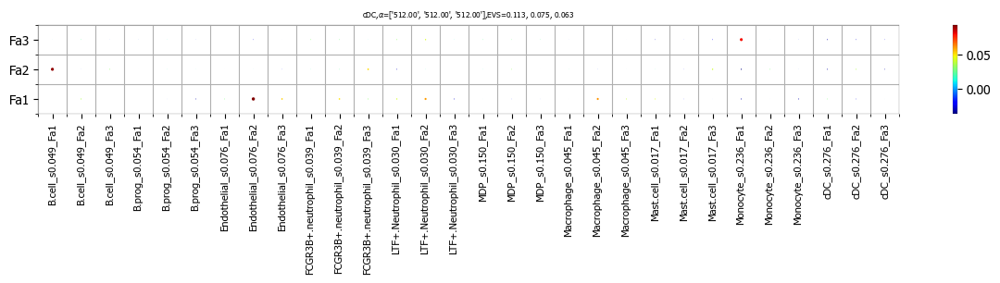

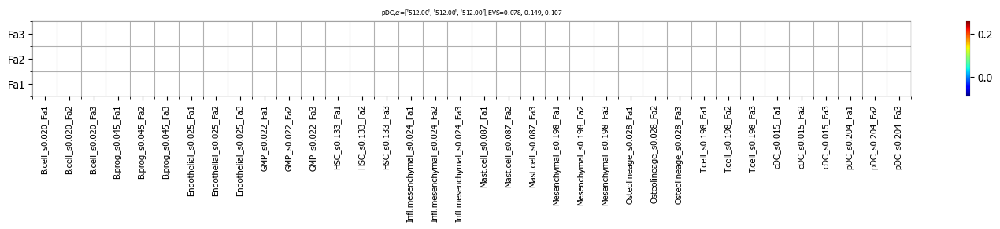

In [54]:
choose_celltypes=[]
scov.plot_significant_regression_covariations_as_circleplot(cov_out,
choose_celltypes=choose_celltypes, 
mention_pvalue=True,
saveas=saveas,transparent_mode=transparent_mode,
figsize=(6,1.25))


In the following example, a p-value cutoff is explicitely defined by the pvalue_cutoff argument and -log10(p-value) is not printed on top of circels. 

The regression figures as pvalue circle plots are saved in following path  ./nico_out0.6/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_*


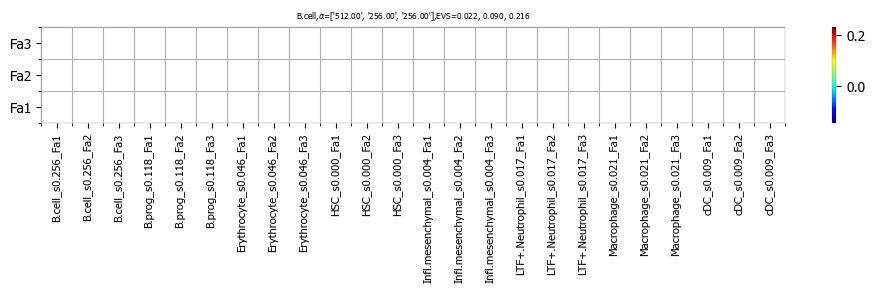

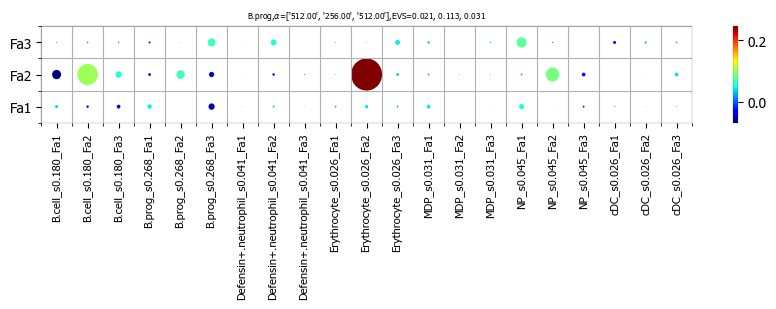

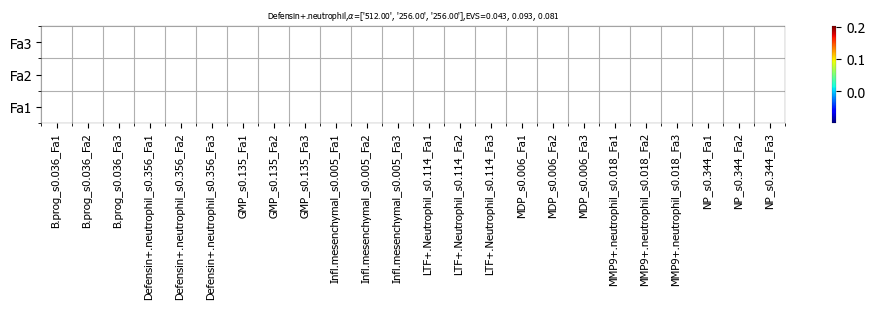

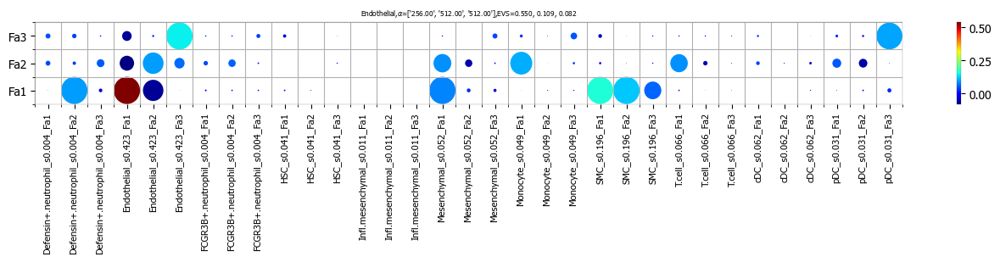

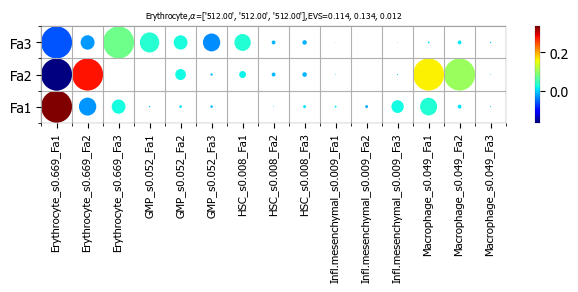

...

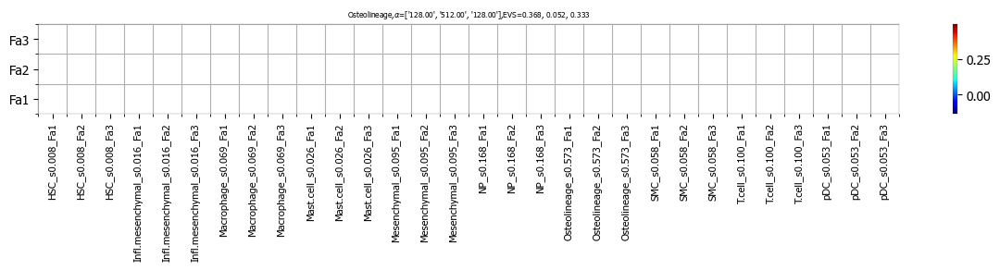

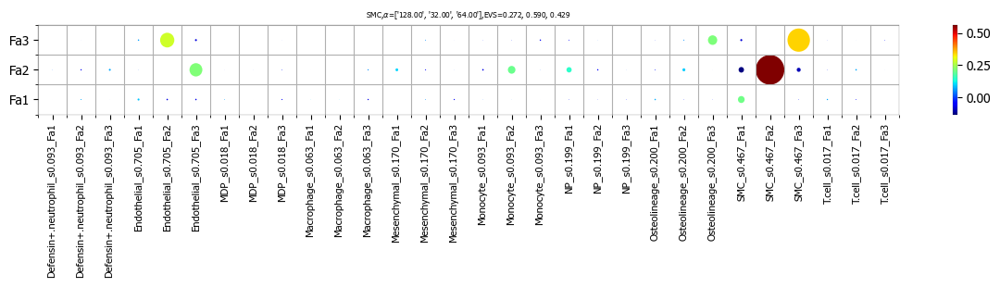

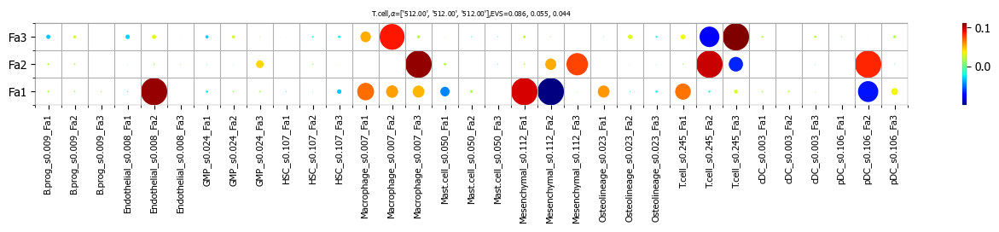

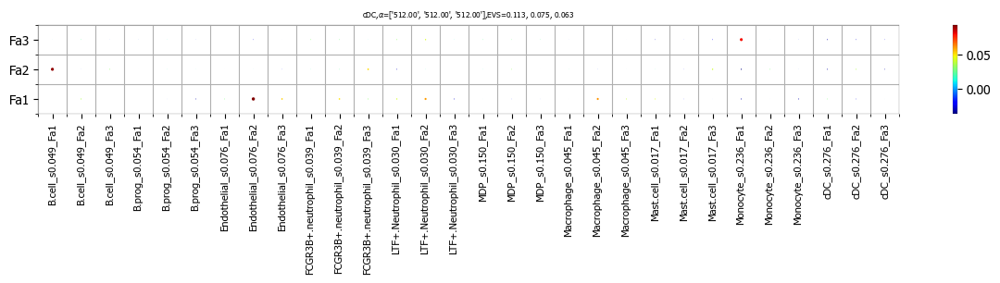

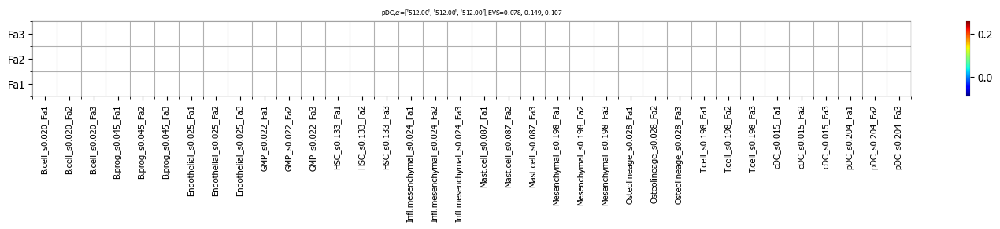

In [55]:
choose_celltypes=[]

scov.plot_significant_regression_covariations_as_circleplot(cov_out,
choose_celltypes=choose_celltypes,
pvalue_cutoff=0.05,mention_pvalue=False,
saveas=saveas,transparent_mode=transparent_mode,
figsize=(6,1.25))


### Visualize as heatmap instead of circle plot 

Plot covariations between niche cell types (x-axis) and central cell type <br>
(y-axis, defined by list argument choose_celltypes) as heatmap.

Leave list argument choose_celltypes empty to generate plots for all cell types. <br>
The top subfigure shows the coefficient and bottom subfigure shows the -log10 p-value. 

In [ ]:
scov.plot_significant_regression_covariations_as_heatmap(cov_out,
choose_celltypes=[],
saveas=saveas,transparent_mode=transparent_mode, figsize=(6,1.25))

# Module E: Analysis of ligand-receptor interactions within the cell type covariation state

### Save excelsheets and summary in text file    
Save all ligand-receptor interactions infered for the niche of each cell type niche in an Excel sheet,  <br>
and a summary of significant niche interactions in a text file. 


In [57]:
scov.save_LR_interactions_in_excelsheet_and_regression_summary_in_textfile_for_interacting_cell_types(cov_out,
pvalueCutoff=0.05,correlation_with_spearman=True,
LR_plot_NMF_Fa_thres=0.1,LR_plot_Exp_thres=0.1,number_of_top_genes_to_print=5)


The Excel sheet is saved:  ./nico_out0.6/covariations_R0_F3/Lig_and_Rec_enrichment_in_interacting_celltypes.xlsx
The text file is saved: ./nico_out0.6/covariations_R0_F3/Regression_summary.txt


### Usage for ligand receptor visualizations 
Perform ligand-receptors analysis <br>
In this example, output is generated for the ligand-receptor pairs associated with the intercting <br>
factor 1 of Stem/TA cells and factor 1 of Paneth cells. 

choose_interacting_celltype_pair=['Stem/TA','Paneth'] <br>
choose_factors_id=[1,1] entries correspond to cell types in <br> choose_interacting_celltype_pai, i.e., <br> 
first factor ID corresponds to Stem/TA and second factor ID corresponds to Paneth

By default, the analysis is saved in 3 separate figures (bidirectional, CC to NC and NC to CC). <br>
CC: central cell  <br>
NC: niche cell <br>

Our analysis accounts for bidirectional cellular crosstalk interactions of ligands and receptors in cell types A and B. <br>
The ligand can be expressed on cell type A and signal to the receptor detected on cell type B, or vice versa.

By changing the cutoff for minimum factor correlation of ligand/receptor genes (LR_plot_NMF_Fa_thres=0.2)  <br>
or the cutoff for the minimum fraction of cells expressing the ligand/receptor genes (LR_plot_Exp_thres=0.2) the  <br>
stringency of the output filtering can be controled. 



In [ ]:
scov.find_LR_interactions_in_interacting_cell_types(cov_out,
choose_interacting_celltype_pair=[],
choose_factors_id=[1,1],
pvalueCutoff=0.05,
LR_plot_NMF_Fa_thres=0.3,
LR_plot_Exp_thres=0.2,
saveas=saveas,transparent_mode=transparent_mode,figsize=(12, 10))

Perform ligand-receptors analysis of the Paneth cell niche <br> 
including all significant interaction partners. <br>
choose_interacting_celltype_pair=['Paneth']  generate <br> plots for all cell types interacting sigificantly with Paneth cells <br>
choose_factors_id=[]  if empty, generate plots <br> for all significantly covarying factors


In [ ]:
scov.find_LR_interactions_in_interacting_cell_types(cov_out,
choose_interacting_celltype_pair=[],
choose_factors_id=[], 
LR_plot_NMF_Fa_thres=0.2,
LR_plot_Exp_thres=0.2,
saveas=saveas,transparent_mode=transparent_mode,figsize=(12, 10))


# Module F: Perform functional enrichment analysis for genes associated with latent factors 

### Perform pathway enrichment analysis for factor-associated genes

In this example, pathway analysis is performed for top 50 (NOG_pathway=50) genes, <br>
positively correlated (positively_correlated=True) with <br>
factor 1 (choose_factors_id=[2]) of Stem/TA cells (choose_celltypes=['Stem/TA']) <br>
testing for enrichment of GO Biological Processes (database=['GO_Biological_Process_2021']).

If savefigure=True, then the figures will be saved in the respective folder. 

In [ ]:
scov.pathway_analysis(cov_out,
choose_celltypes=[],
NOG_pathway=50,
choose_factors_id=[2],
positively_correlated=True,
savefigure=False,
database=['GO_Biological_Process_2021'])

In this example, pathway analysis is performed for top 50 (NOG_pathway=50) genes, <br>
negatively correlated (positively_correlated=False)  <br>
with factor 1 (choose_factors_id=[2]) <br>
of Stem/TA cells (choose_celltypes=['Stem/TA']) <br>
testing for enrichment of GO Biological Processes (database=['GO_Biological_Process_2021']).

If savefigure=True, then the figures will be saved in the respective folder. 


In [ ]:
scov.pathway_analysis(cov_out,
choose_celltypes=[],
NOG_pathway=50,
choose_factors_id=[2],
positively_correlated=False,
savefigure=False,
database=['GO_Biological_Process_2021'])

In this example, pathway analyses are performed for top 50 (NOG_pathway=50) genes, <br>
positively correlated (positively_correlated=True)  <br>
with any factor (choose_factors_id=[]) <br>
of Paneth cells (choose_celltypes=['Paneth']) <br>
ribosome and mitochondrial genes are not included in the gene list  <br>
testing for enrichment of pathways from three databases  <br> 

(GO_Biological_Process_2021, BioPlanet_2019, Reactome_2016).


In [ ]:
scov.pathway_analysis(cov_out,
choose_celltypes=[],
NOG_pathway=50,
choose_factors_id=[],
positively_correlated=True,
savefigure=False,
rps_rpl_mt_genes_included=False)


# Module G: Visualization of top genes across cell type and factors as dotplot

Show the top 20 positively and negatively correlated genes (top_NOG=20) for all latent factors and <br>
the average expression of these genes on a log scale in a single plot. <br>
In this example, plots are generated for Paneth cells.  

If the choose_celltypes=[], the plot will be generated for all cell types. 

The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/Bcell.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/Bprog.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/Defensinpneutrophil.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/Endothelial.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/Erythrocyte.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/FCGR3Bpneutrophil.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/GMP.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/HSC.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/Inflmesenchymal.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/LTFpNeutrophil.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/MDP.png
The figures are saved:  ./nico_out0.6/covariations_R0_F3/dotplots/MEP.png
The figures are saved:  ./nico_out0.6/c

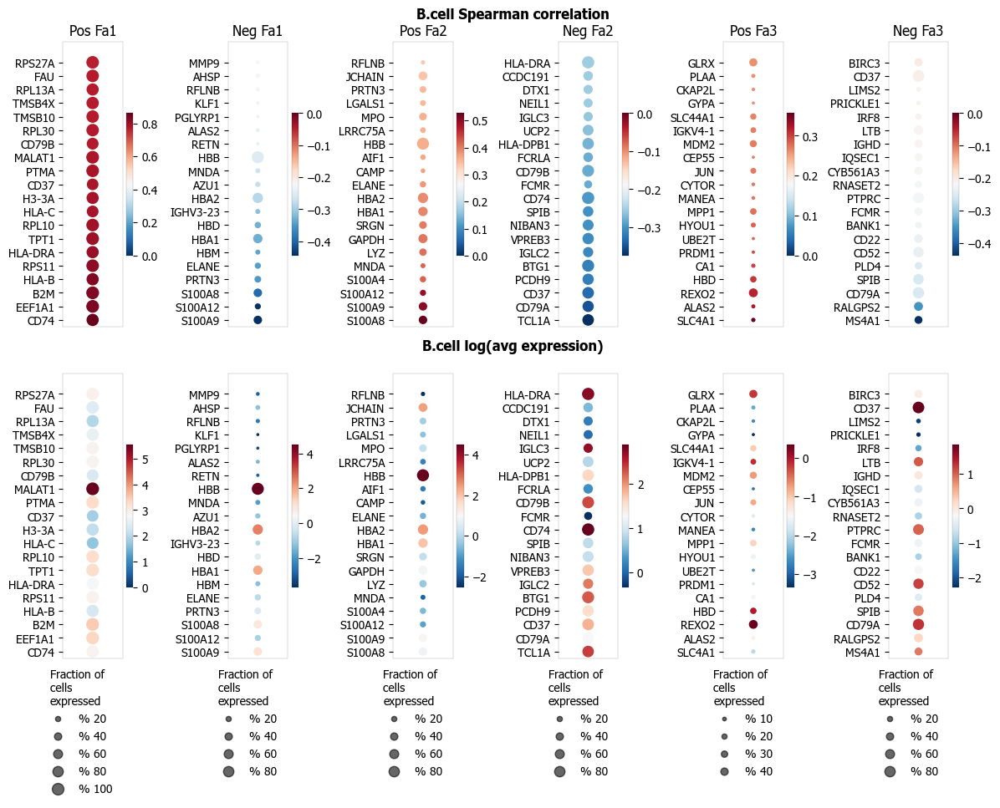

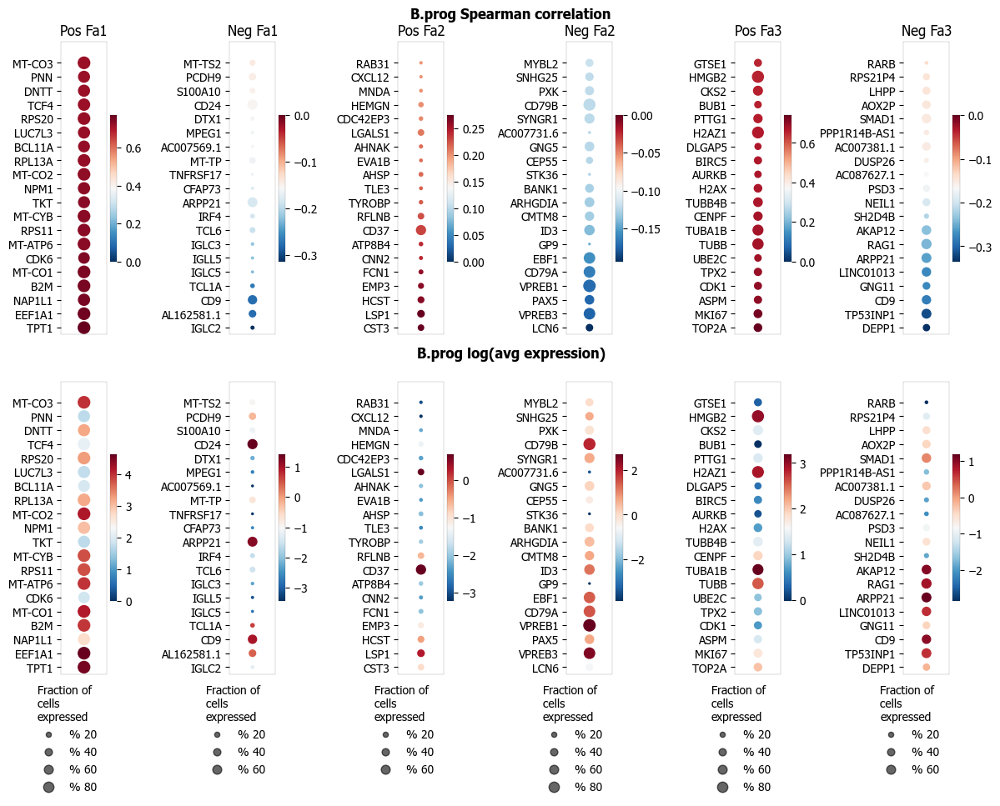

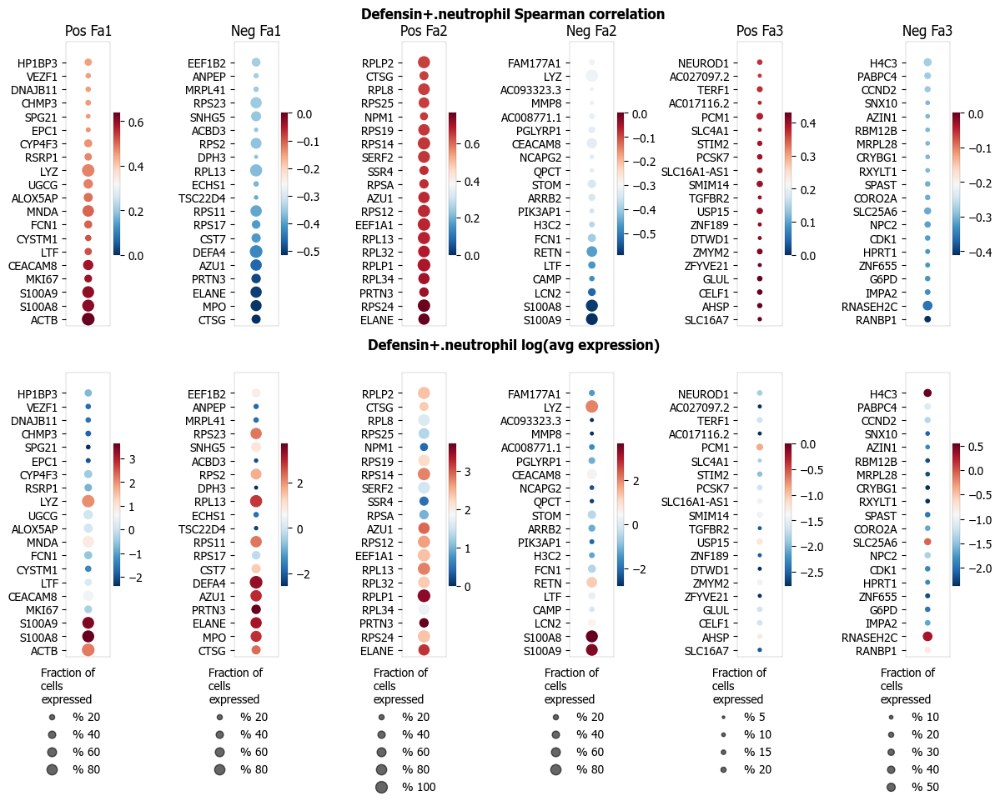

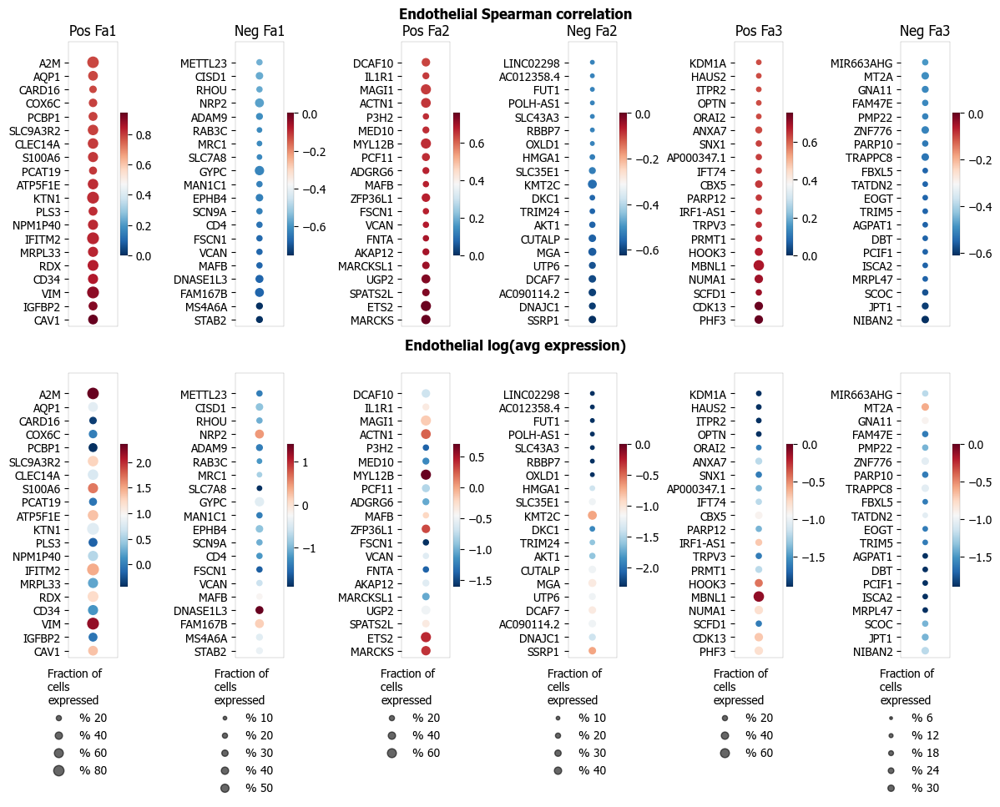

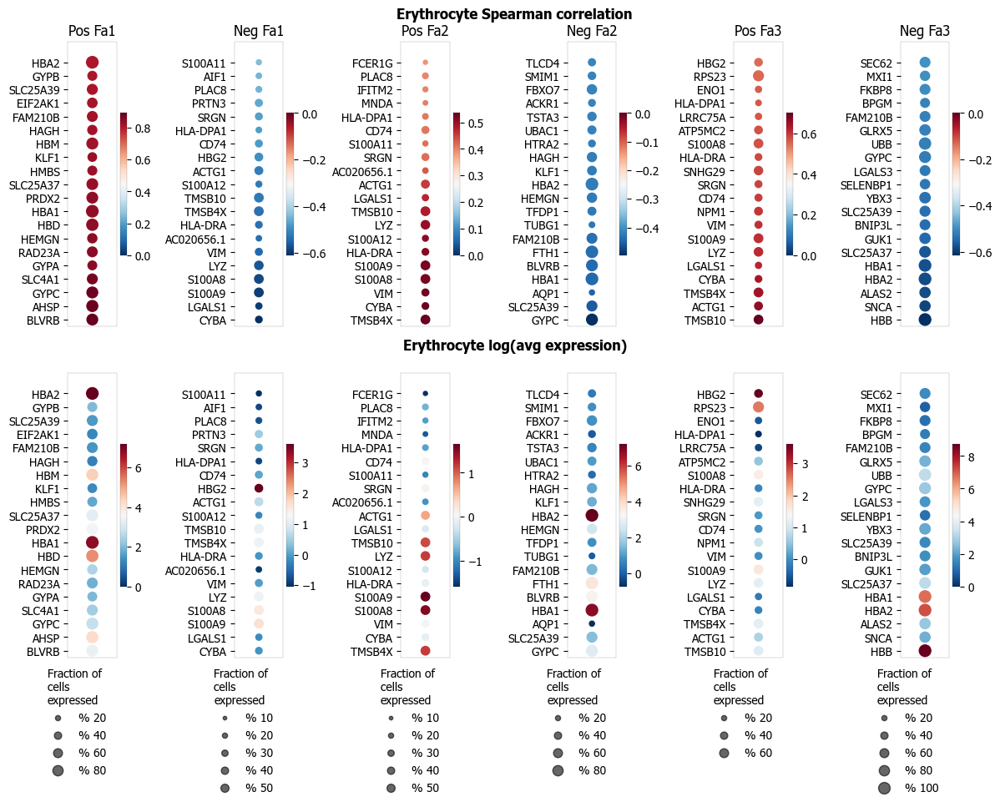

...

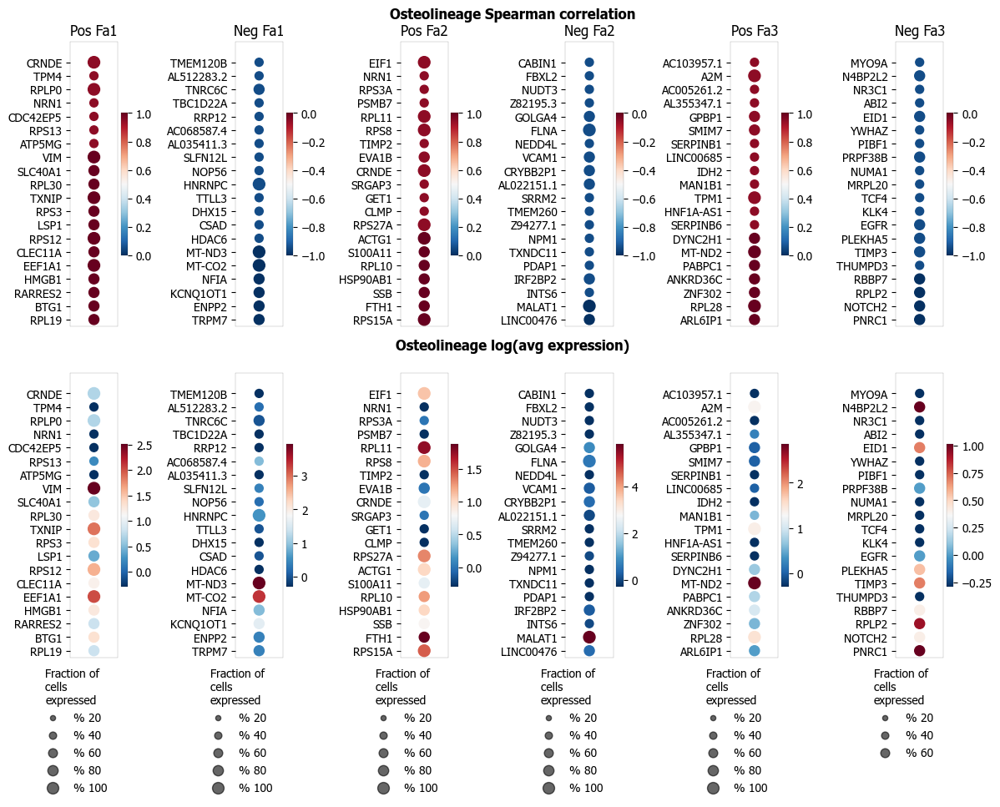

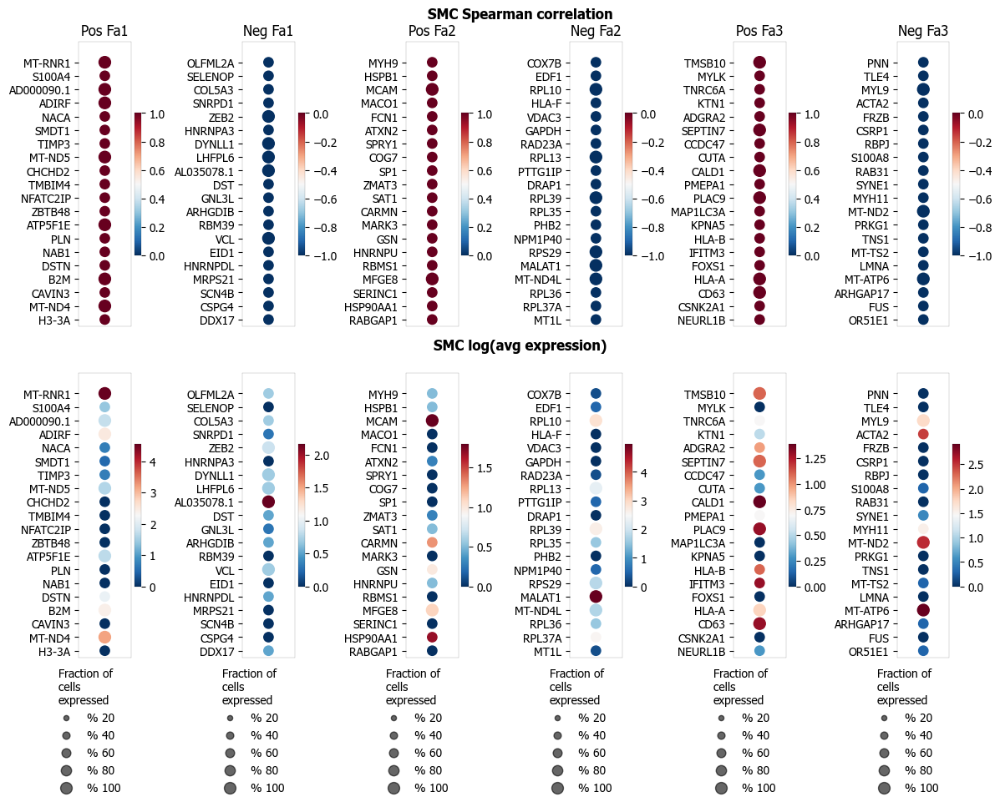

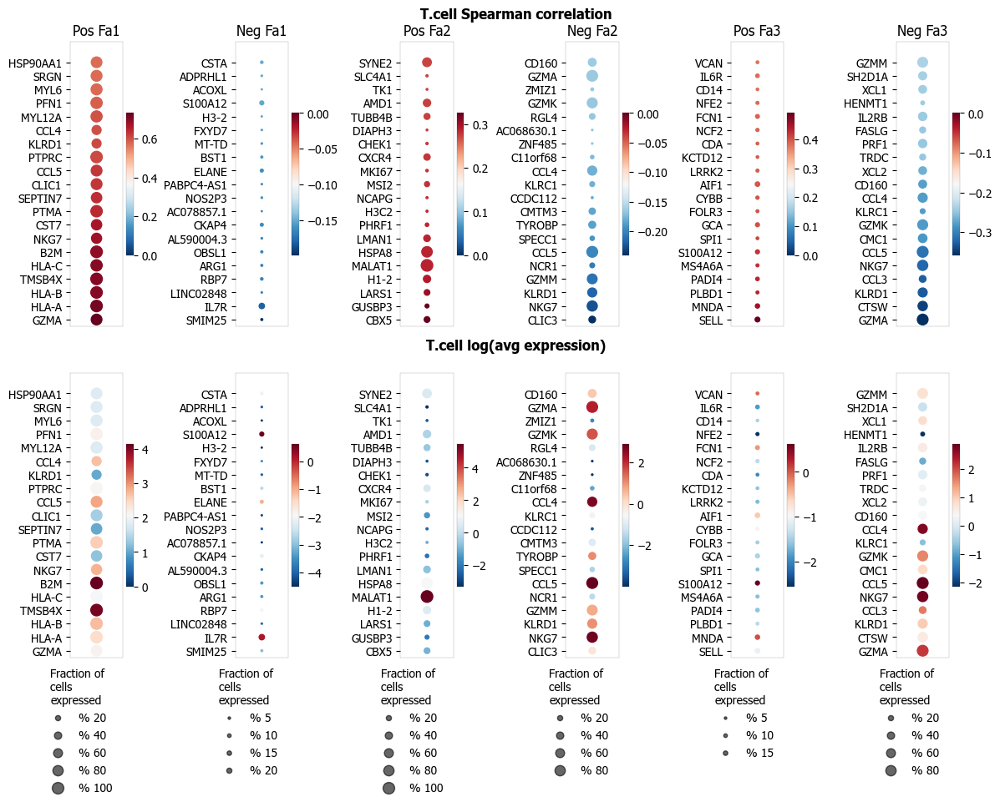

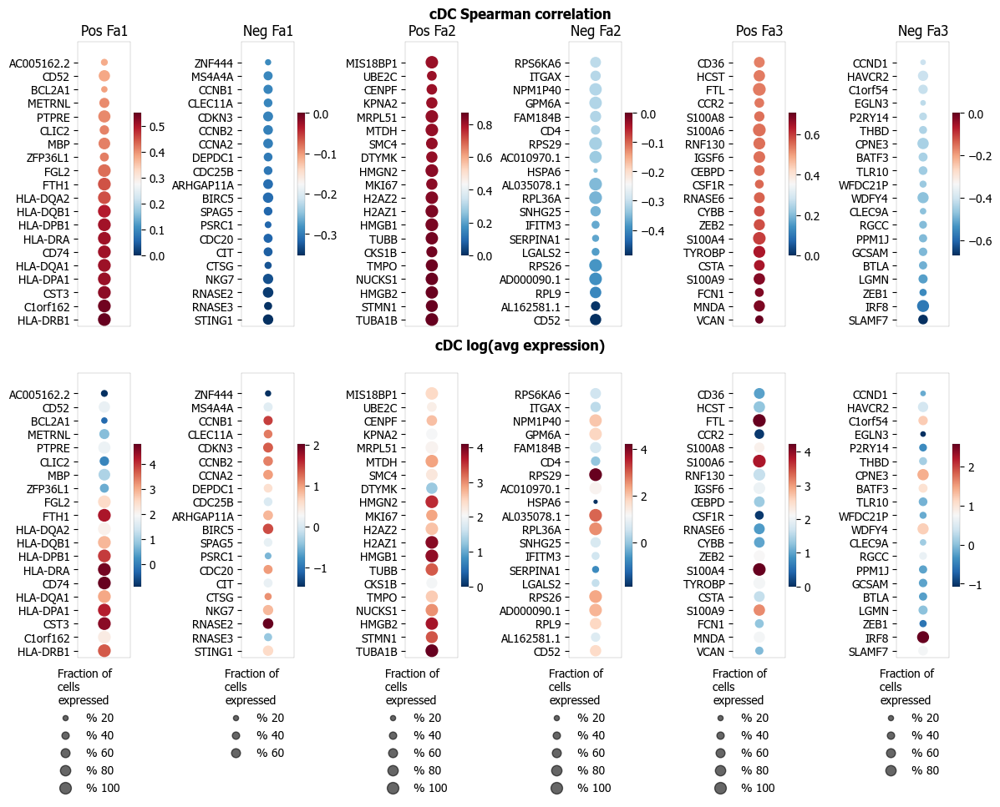

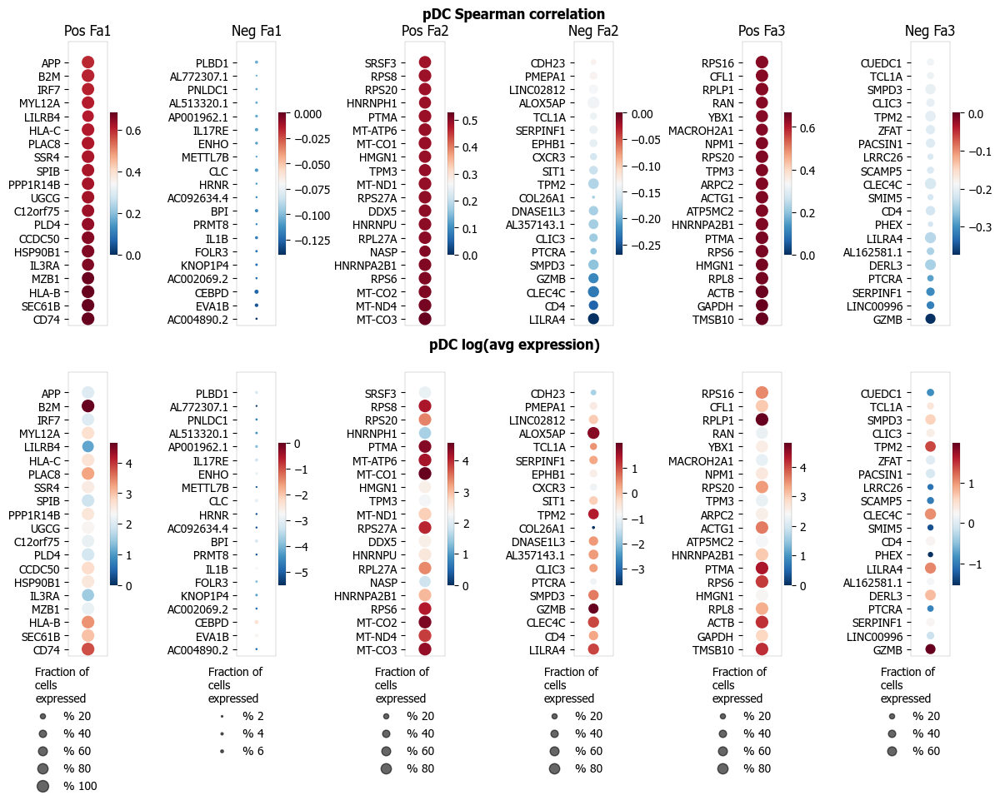

In [64]:
scov.plot_top_genes_for_a_given_celltype_from_all_three_factors(
cov_out,choose_celltypes=[],
top_NOG=20,saveas=saveas,transparent_mode=transparent_mode)
                        